In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from scipy.optimize import minimize

Burgers' equation in 1 spatial dimension is the PDE:
$$\frac{\partial u}{\partial t} + u\frac{\partial u}{\partial x} = \nu\frac{\partial^2 u}{\partial x^2}$$

Let us choose the initial and boundary conditions, and diffusion coefficient $\nu$:
$$u(0,x) = -\sin(\pi x)$$
$$u(t,-1) = u(t,1) = 0$$
$$\nu = \frac{0.01}{\pi}$$

We want the function
$$f = \frac{\partial u}{\partial t} + u\frac{\partial u}{\partial x} - \nu\frac{\partial^2 u}{\partial x^2}$$
to go to zero. So we minimize $|f|^2$.

In simulations, we would've evolved $u(0,x)$ using the PDE. Here, we approximate $u(t,x)$ with a dense neural network.

The total loss function is
$$L = \frac{1}{N_\mathrm{bound}} \sum_{i\in\mathrm{bound}}^{N_\mathrm{bound}} \left|u_{\mathrm{NN}}(t_u^i,x_u^i) - u^i\right|^2 + \phi\cdot\frac{1}{N_\mathrm{bulk}} \sum_{i\in\mathrm{bulk}}^{N_\mathrm{bulk}} \left|f_{\mathrm{NN}}(t_f^i,x_f^i)\right|^2$$
where $\phi$ modulates the relative importance of minimizing $|f|^2$.

In [21]:
class NeuralNetwork:
    def __init__(self, width, depth) -> None:
        self.model = self.get_model(width, depth)
        self.nu = 0.01/np.pi  # diffusion coefficient or kinematic viscosity
        self.N_U = 1000  # number of boundary points
        self.N_F = 10_000  # number of bulk points
        self.f_factor = 1.  # relative importance of bulk
    
    def get_model(self, width, depth):
        model = keras.models.Sequential()
        model.add(keras.layers.InputLayer(shape=(2,)))
        for _ in range(depth):
            model.add(keras.layers.Dense(width, activation='tanh'))
        model.add(keras.layers.Dense(1, activation=None))
        return model
    
    def u(self, t, x):
        y = tf.stack([t, x], axis=-1)
        return self.model(y)[:,0]
    
    def f(self, t, x):
        with tf.GradientTape(persistent=True) as tape_outer:
            tape_outer.watch([t, x])
            with tf.GradientTape(persistent=True) as tape_inner:
                tape_inner.watch([t, x])
                u_ = self.u(t, x)
            u_t, u_x = tape_inner.gradient(u_, [t, x])
        u_xx = tape_outer.gradient(u_x, x)
        del tape_inner, tape_outer
        f = u_t + u_*u_x - self.nu*u_xx
        return f
    
    def boundary_t0(self):
        x = np.random.uniform(-1, 1, size=self.N_U).astype(np.float32)
        t = np.zeros_like(x, dtype=np.float32)
        u = - np.sin(np.pi * x).astype(np.float32)
        return t, x, u

    def boundary_x(self):
        t = np.random.uniform(0, 1, size=self.N_U).astype(np.float32)
        x = np.concatenate([np.ones(self.N_U//2), - np.ones(self.N_U-self.N_U//2)]).astype(np.float32)
        u = np.zeros_like(t, dtype=np.float32)
        return t, x, u

    def get_loss(self):
        t_bound, x_bound, u_bound = [
        tf.concat([v_t0, v_x], axis=0) for v_t0, v_x in zip(self.boundary_t0(), self.boundary_x())
        ]
        loss_u = tf.reduce_mean(tf.square(self.u(t_bound, x_bound) - u_bound))

        t_bulk = tf.convert_to_tensor(np.random.uniform(0, 1, size=self.N_F), dtype=tf.float32)
        x_bulk = tf.convert_to_tensor(np.random.uniform(-1, 1, size=self.N_F), dtype=tf.float32)
        loss_f = tf.reduce_mean(tf.square(self.f(t_bulk, x_bulk)))

        loss = loss_u + self.f_factor * loss_f
        return loss, loss_u, loss_f

    @tf.function
    def train_step(self, optimizer):
        with tf.GradientTape() as tape:
            loss, loss_u, loss_f = self.get_loss()
        grads = tape.gradient(loss, self.model.trainable_variables)
        optimizer.apply_gradients(zip(grads, self.model.trainable_variables))
        return loss, loss_u, loss_f
    
    def show_state(self, title=''):
        N_T = 64 + 1
        N_X = 128
        grid_tx = np.meshgrid(np.linspace(0, 1, N_T), np.linspace(-1, 1, N_X), indexing='ij')
        grid_t, grid_x = [tf.convert_to_tensor(t, tf.float32) for t in grid_tx]
        grid_u = self.u(tf.reshape(grid_t, (N_T*N_X,)), tf.reshape(grid_x, (N_T*N_X,)))
        grid_u = tf.reshape(grid_u, (N_T, N_X))
        fig, ax = plt.subplots(1, 1, figsize=(20, 4))
        im = ax.imshow(tf.transpose(grid_u), origin='lower', aspect='auto', extent=(0, 1, -1, 1), cmap='viridis')
        ax.axhline(0, c='k', ls='--')
        plt.colorbar(im)
        ax.set_xlabel('t')
        ax.set_ylabel('x')
        ax.set_title(title)
        return fig, ax

In [22]:
neural_network = NeuralNetwork(width=20, depth=8)
_ = neural_network.model(tf.zeros((1, 2), dtype=tf.float32))

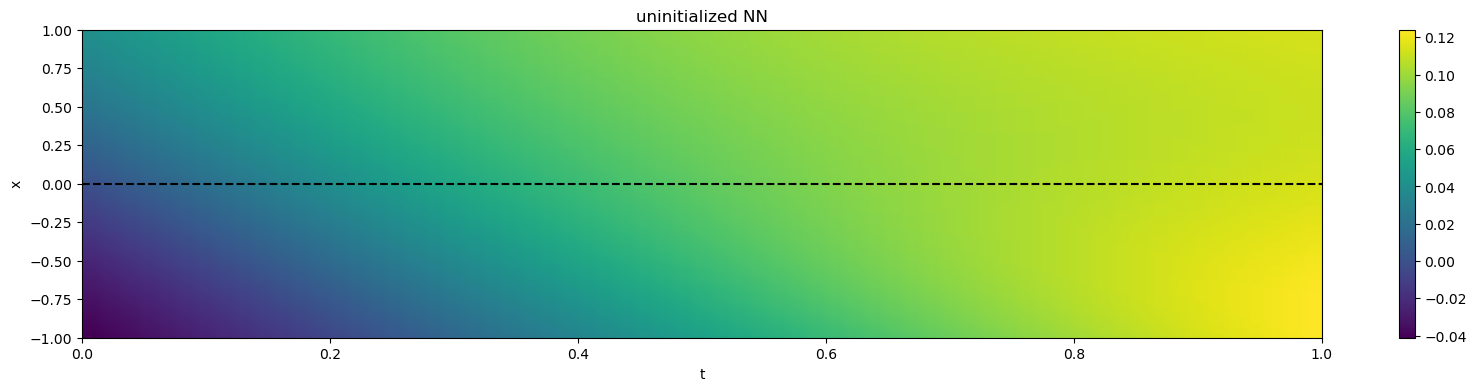

In [23]:
neural_network.show_state("uninitialized NN");

In [24]:
# optimizer = keras.optimizers.SGD(learning_rate=0.02)
optimizer = keras.optimizers.Adam(learning_rate=1e-3)
neural_network.model.compile(optimizer)

In [25]:
EPOCHS = 5000
history = {"loss": [], "loss_u": [], "loss_f": []}
for epoch in range(1, EPOCHS + 1):
    loss, loss_u, loss_f = neural_network.train_step(optimizer)
    history["loss"].append(float(loss))
    history["loss_u"].append(float(loss_u))
    history["loss_f"].append(float(loss_f))
    if epoch % 500 == 0 or epoch == 1:
        print(f"epoch {epoch:5d} | loss {loss:.4e} | loss_u {loss_u:.2e} | loss_f {loss_f:.2e}")
    # if epoch % 2500 == 0:
    #     new_LR = optimizer.learning_rate.numpy() / 2
    #     optimizer.learning_rate.assign(new_LR)

epoch     1 | loss 2.8485e-01 | loss_u 2.68e-01 | loss_f 1.73e-02
epoch   500 | loss 5.5845e-02 | loss_u 4.01e-02 | loss_f 1.58e-02
epoch  1000 | loss 1.8886e-02 | loss_u 1.19e-02 | loss_f 6.98e-03
epoch  1500 | loss 4.7985e-03 | loss_u 2.04e-03 | loss_f 2.76e-03
epoch  2000 | loss 2.3370e-03 | loss_u 9.14e-04 | loss_f 1.42e-03
epoch  2500 | loss 2.6041e-03 | loss_u 5.03e-04 | loss_f 2.10e-03
epoch  3000 | loss 8.6700e-04 | loss_u 3.29e-04 | loss_f 5.38e-04
epoch  3500 | loss 8.1916e-04 | loss_u 3.55e-04 | loss_f 4.64e-04
epoch  4000 | loss 4.0377e-04 | loss_u 1.03e-04 | loss_f 3.01e-04
epoch  4500 | loss 4.6043e-04 | loss_u 9.52e-05 | loss_f 3.65e-04
epoch  5000 | loss 3.5761e-04 | loss_u 8.47e-05 | loss_f 2.73e-04


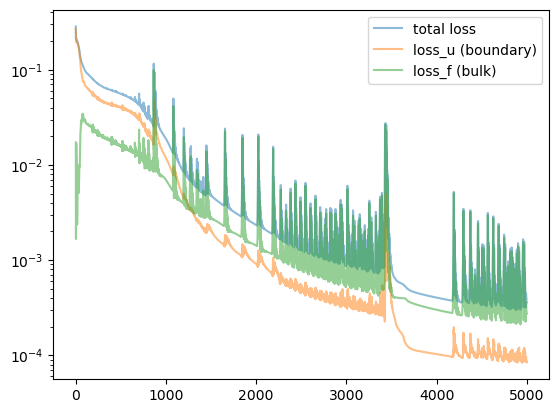

In [26]:
plt.yscale('log')
plt.plot(history['loss'], alpha=0.5, label='total loss')
plt.plot(history['loss_u'], alpha=0.5, label='loss_u (boundary)')
plt.plot(history['loss_f'], alpha=0.5, label='loss_f (bulk)')
plt.legend();

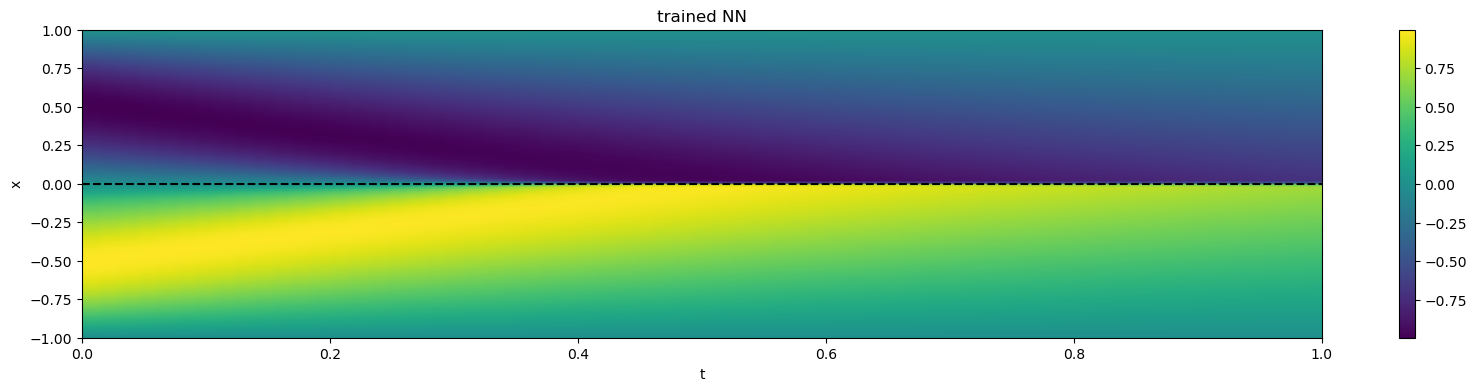

In [27]:
neural_network.show_state("trained NN");

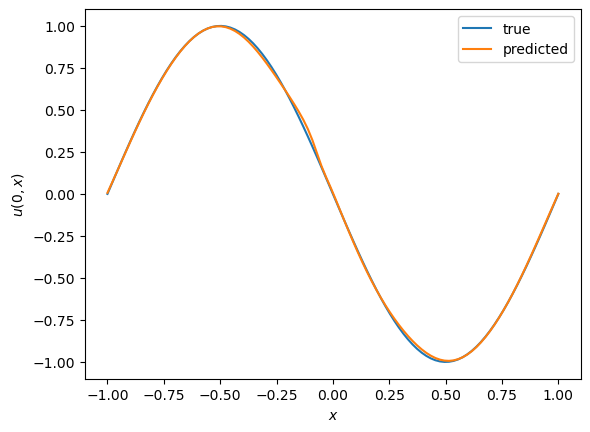

In [28]:
plt.plot(np.linspace(-1, 1, 100), -np.sin(np.pi * np.linspace(-1, 1, 100)), label="true")
plt.plot(np.linspace(-1, 1, 100), neural_network.u(
    tf.zeros(100), tf.convert_to_tensor(np.linspace(-1, 1, 100), dtype=tf.float32)
), label="predicted")
plt.xlabel('$x$')
plt.ylabel('$u(0,x)$')
plt.legend();

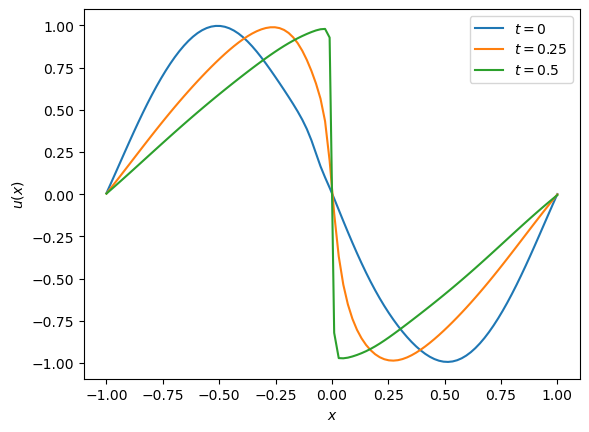

In [29]:
plt.plot(np.linspace(-1, 1, 100), neural_network.u(
    tf.zeros(100), tf.convert_to_tensor(np.linspace(-1, 1, 100), dtype=tf.float32)
), label="$t = 0$")
plt.plot(np.linspace(-1, 1, 100), neural_network.u(
    tf.zeros(100)+0.25, tf.convert_to_tensor(np.linspace(-1, 1, 100), dtype=tf.float32)
), label="$t = 0.25$")
plt.plot(np.linspace(-1, 1, 100), neural_network.u(
    tf.zeros(100)+0.5, tf.convert_to_tensor(np.linspace(-1, 1, 100), dtype=tf.float32)
), label="$t = 0.5$")
plt.xlabel('$x$')
plt.ylabel('$u(x)$')
plt.legend();

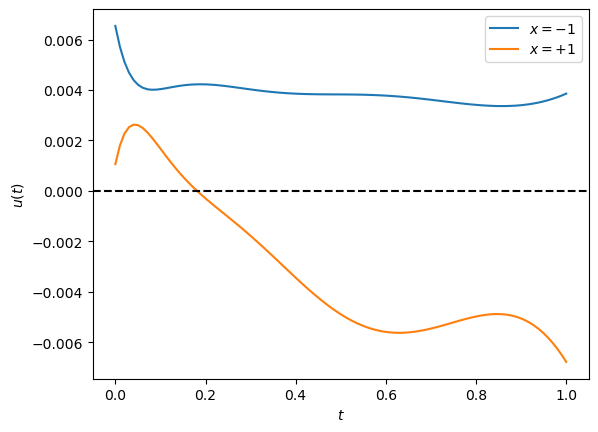

In [30]:
plt.plot(np.linspace(0, 1, 100), neural_network.u(
    tf.convert_to_tensor(np.linspace(0, 1, 100), dtype=tf.float32), -tf.ones(100)
), label="$x = -1$")
plt.plot(np.linspace(0, 1, 100), neural_network.u(
    tf.convert_to_tensor(np.linspace(0, 1, 100), dtype=tf.float32), tf.ones(100)
), label="$x = +1$")
plt.axhline(0, c='k', ls='--')
plt.xlabel('$t$')
plt.ylabel('$u(t)$')
plt.legend();

# Fine-tuning with LBFGS

In [31]:
EPOCHS_LBFGS = 10_000

In [32]:
# Flatten / unflatten helpers
shapes = [v.shape for v in neural_network.model.trainable_variables]
sizes  = [tf.size(v).numpy() for v in neural_network.model.trainable_variables]

In [33]:
def pack(variables):
    return np.concatenate([v.numpy().ravel() for v in variables])

def unpack(flat):
    vs, idx = [], 0
    for shape, size in zip(shapes, sizes):
        vs.append(flat[idx: idx + size].reshape(shape))
        idx += size
    return vs

def loss_and_grads(flat_params):
    for var, val in zip(neural_network.model.trainable_variables, unpack(flat_params)):
        var.assign(val)
    with tf.GradientTape() as tape:
        loss, loss_u, loss_f = neural_network.get_loss()
    grads = tape.gradient(loss, neural_network.model.trainable_variables)
    flat_grads = np.concatenate([g.numpy().ravel() for g in grads])
    return float(loss), flat_grads.astype(np.float64)

In [34]:
lbfgs_losses = []
iter_count   = [0]

In [35]:

def callback(flat_params):
    loss_val, _ = loss_and_grads(flat_params)
    lbfgs_losses.append(loss_val)
    iter_count[0] += 1
    if iter_count[0] % 100 == 0:
        print(f"  L-BFGS iter {iter_count[0]:5d} | Loss {loss_val:.4e}")

In [36]:
x0 = pack(neural_network.model.trainable_variables).astype(np.float64)
result = minimize(
    loss_and_grads, x0,
    method="L-BFGS-B",
    jac=True,
    callback=callback,
    options={"maxiter": EPOCHS_LBFGS, "ftol": 1e-12, "gtol": 1e-8, "maxfun": 50_000},
)

In [39]:
result

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 0.0004127015999983996
        x: [ 3.295e-01  1.402e-01 ...  3.894e-01  4.723e-04]
      nit: 6
      jac: [ 4.539e-03 -3.175e-03 ...  2.265e-03  2.585e-02]
     nfev: 19
     njev: 19
 hess_inv: <3021x3021 LbfgsInvHessProduct with dtype=float64>

In [37]:
# Load best params
for var, val in zip(neural_network.model.trainable_variables, unpack(result.x)):
    var.assign(val)

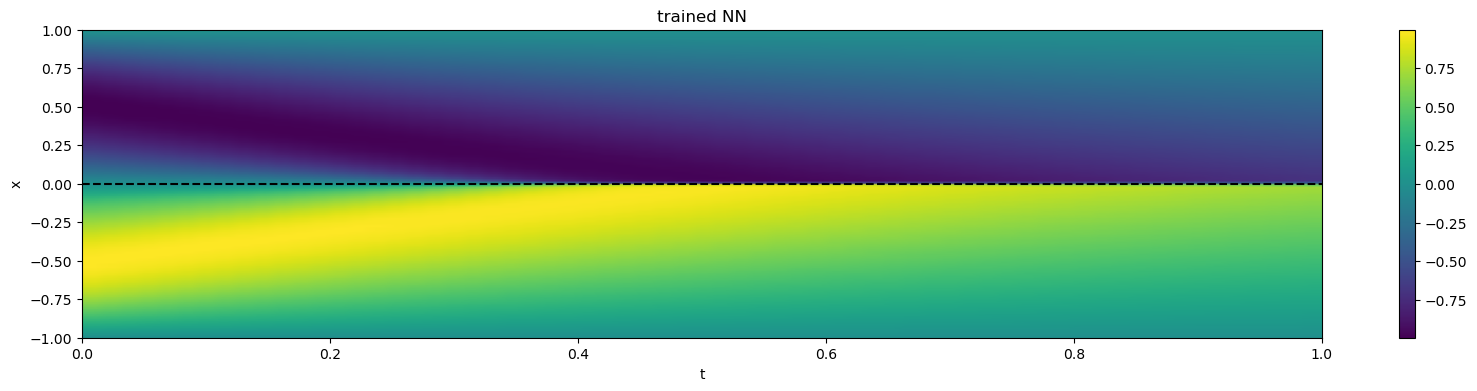

In [38]:
neural_network.show_state("trained NN");